In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import re

In [15]:
def load_data():
    
    data_dir = Path("../results")
    
    files = data_dir.glob("*.csv")
    
    regex = re.compile("results_maxDelay=(\d\.\d)s.csv")
    
    dfs = []
    
    for f in files:
        
        f_match = regex.match(f.name)
        
        if f_match:
            
            tmp = pd.read_csv(f)
            tmp.columns = ["N_requests", "N_semaphores", "Duration"]
            tmp["Delay"] = float(f_match.groups()[0])
            
            dfs.append(tmp)
            
    df = pd.concat(dfs, axis=0)
    df["Duration_per_request"] = df["Duration"] / df["N_requests"]
    df["Requests_per_min"] = 60 / df["Duration_per_request"]
    
    return df

In [16]:
df  = load_data()

In [17]:
df.head()

,N_requests,N_semaphores,Duration,Delay,Duration_per_request,Requests_per_min
0,1000,1000,2.283757,1.0,0.002284,26272.500919
1,1000,2000,1.352880,1.0,0.001353,44349.822029
2,1000,4000,1.323480,1.0,0.001323,45335.034131
3,1000,6000,1.323900,1.0,0.001324,45320.659677
4,1000,8000,1.359654,1.0,0.001360,44128.875976


# How does the duration change with number of requests for each requestion duration?

In [5]:
pivot_df = df.groupby("Delay").apply(lambda x: pd.pivot_table(x, values="Duration", index="N_requests", columns="N_semaphores"))

/tmp/ipykernel_155185/532994816.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pivot_df = df.groupby("Delay").apply(lambda x: pd.pivot_table(x, values="Duration", index="N_requests", columns="N_semaphores"))


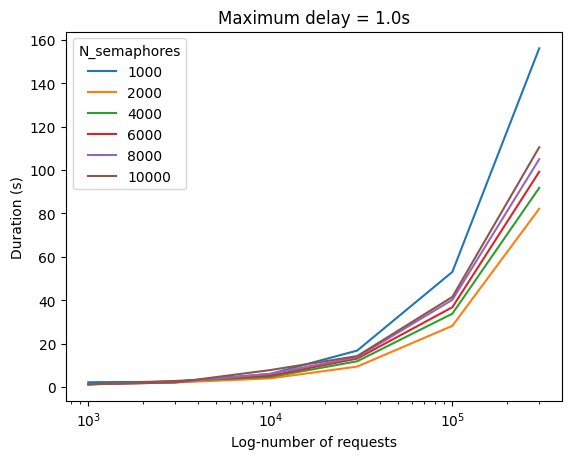

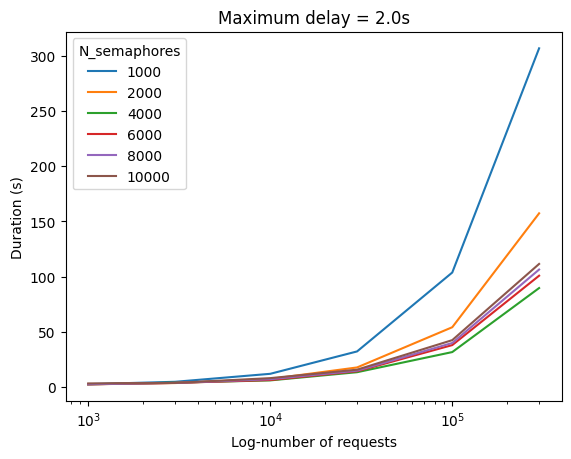

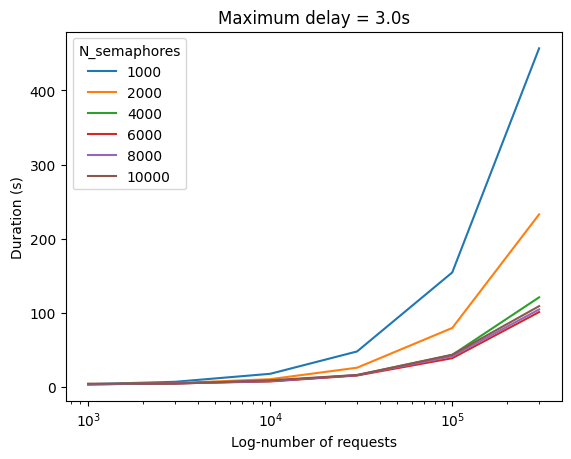

In [11]:
for i, g in pivot_df.groupby("Delay"):
    
    g.droplevel(0).plot(title=f"Maximum delay = {i}s")
    plt.gca().set_xscale("log")
    plt.gca().set_xlabel("Log-number of requests")
    plt.gca().set_ylabel("Duration (s)")
    

# How does the duration change for each semaphore count?

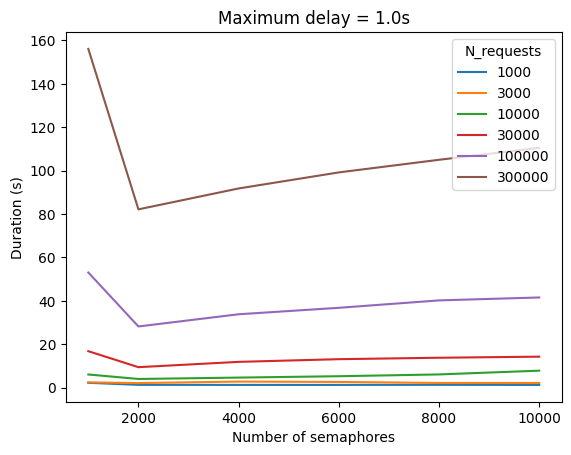

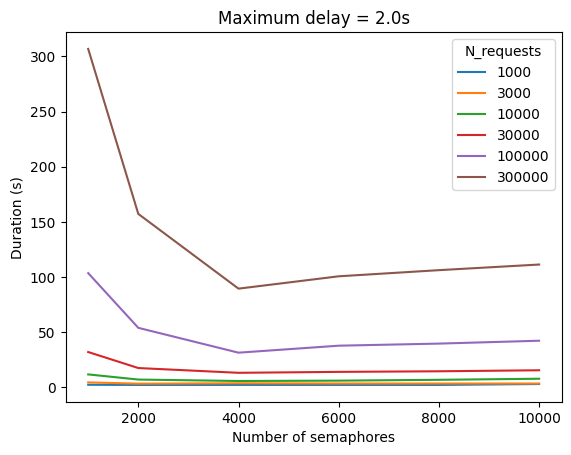

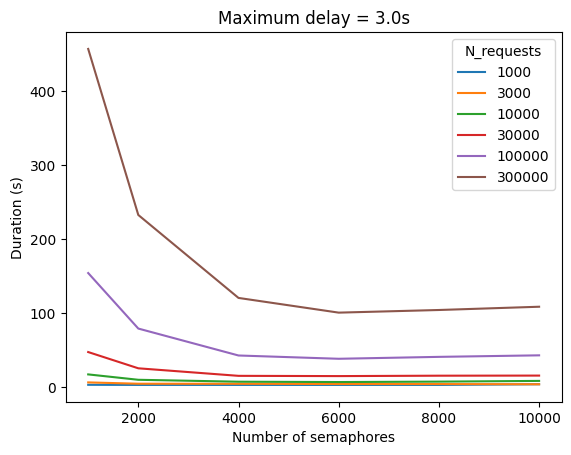

In [14]:
for i, g in pivot_df.groupby("Delay"):
    
    g.droplevel(0).T.plot(title=f"Maximum delay = {i}s")
    plt.gca().set_xlabel("Number of semaphores")
    plt.gca().set_ylabel("Duration (s)")